# Phase 0 — EDA initiale sur FD001

Objectif : tracer quelques trajectoires de capteurs et calculer la variance de chaque capteur,
pour repérer ceux qui sont constants (ils n'apportent aucune information et seront exclus du
pipeline de préparation en Phase 1).

Critère « fait » (plan d'exécution, Phase 0) : liste des capteurs constants établie sur FD001.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../DATA/CMaps")

# Mêmes noms de colonnes que dans 01_data_loading_check.ipynb (21 capteurs réels,
# malgré la coquille du readme qui parle de "sensor measurement 26").
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None)
train = train.iloc[:, : len(COL_NAMES)]
train.columns = COL_NAMES
train.shape

(20631, 26)

In [2]:
# Écart-type de chaque capteur sur l'ensemble du train FD001.
# Un capteur "constant" (std ~ 0) ne varie jamais : aucune information utile pour
# prédire le RUL, on l'exclura du pipeline en Phase 1.
sensor_std = train[SENSOR_NAMES].std().sort_values()

CONSTANT_THRESHOLD = 1e-5
constant_sensors = sensor_std[sensor_std < CONSTANT_THRESHOLD].index.tolist()

print("Écart-type par capteur (croissant) :")
print(sensor_std)
print("\nCapteurs constants détectés (std <", CONSTANT_THRESHOLD, "):", constant_sensors)

Écart-type par capteur (croissant) :
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

Capteurs constants détectés (std < 1e-05 ): ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']


In [3]:
# sensor_6 a un écart-type de ~1.4e-3 : trop élevé pour le seuil "constant" ci-dessus,
# mais la littérature sur FD001 le cite comme quasi-constant (il ne prend que 2 valeurs
# discrètes, rarement différentes). On distingue donc explicitement les capteurs à très
# faible cardinalité, sans changer le seuil strict utilisé pour les vrais constants.
QUASI_CONSTANT_MAX_UNIQUE = 5
sensor_nunique = train[SENSOR_NAMES].nunique().sort_values()

quasi_constant_sensors = [
    s for s in sensor_nunique[sensor_nunique <= QUASI_CONSTANT_MAX_UNIQUE].index
    if s not in constant_sensors
]

print("Nombre de valeurs uniques par capteur (les 8 plus faibles) :")
print(sensor_nunique.head(8))
print("\nCapteurs quasi-constants (peu de valeurs uniques, hors constants stricts) :", quasi_constant_sensors)

Nombre de valeurs uniques par capteur (les 8 plus faibles) :
sensor_1      1
sensor_5      1
sensor_16     1
sensor_10     1
sensor_19     1
sensor_18     1
sensor_6      2
sensor_17    13
dtype: int64

Capteurs quasi-constants (peu de valeurs uniques, hors constants stricts) : ['sensor_6']


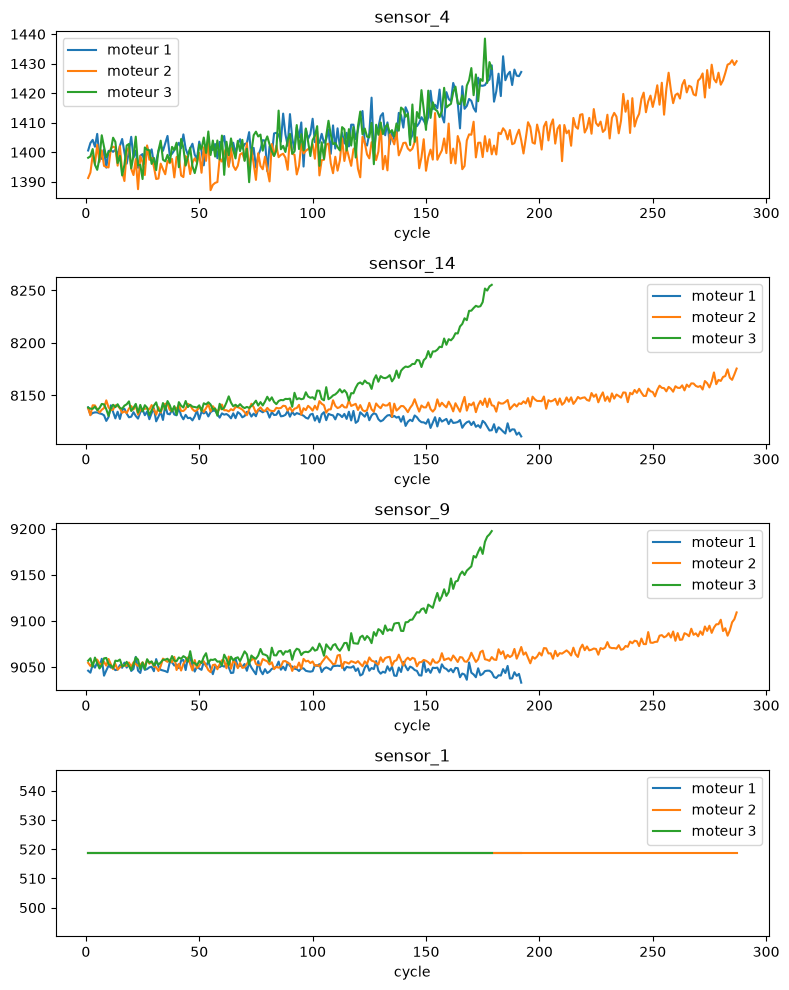

In [4]:
# Trajectoires de quelques moteurs pour un échantillon de capteurs : 3 capteurs
# à forte variance (tendance de dégradation attendue) + 1 capteur constant en
# contre-exemple, pour vérifier visuellement le diagnostic ci-dessus.
sample_units = [1, 2, 3]
sensors_to_plot = sensor_std.index[-3:].tolist() + constant_sensors[:1]

fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(8, 2.5 * len(sensors_to_plot)), sharex=False)

for ax, sensor in zip(axes, sensors_to_plot):
    for unit in sample_units:
        unit_data = train[train["unit_number"] == unit]
        ax.plot(unit_data["time_cycles"], unit_data[sensor], label=f"moteur {unit}")
    ax.set_title(sensor)
    ax.set_xlabel("cycle")
    ax.legend()

fig.tight_layout()